## Imports

In [19]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

from src.models.sabr import SABRModel
from src.models.heston import HestonModel

from src.pricing.black_scholes import implied_volatility_brent
from src.pricing.sabr_formula import hagan_implied_volatility
from src.pricing.heston_pricer import heston_implied_volatility

from src.calibration.optimizers import (
    calibrate_sabr_smile,
    calibrate_heston_surface,
)

## Parameters

In [27]:
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)

spot = float(ticker.history(period="1d")["Close"].iloc[-1])

rate = 0.04
dividend_yield = 0.0

today = pd.Timestamp.today().normalize()

expiries = list(ticker.options)

selected_expiries = [
    expiry for expiry in expiries
    if 30 <= (pd.Timestamp(expiry) - today).days <= 365
][:6]

spot, selected_expiries

(739.1699829101562,
 ['2026-06-18',
  '2026-06-26',
  '2026-06-30',
  '2026-07-17',
  '2026-07-31',
  '2026-08-21'])

In [28]:
all_rows = []

for expiry in selected_expiries:
    chain = ticker.option_chain(expiry)
    calls = chain.calls.copy()

    expiry_date = pd.Timestamp(expiry)
    maturity = (expiry_date - today).days / 365.0

    calls["expiry"] = expiry
    calls["maturity"] = maturity
    calls["mid"] = (calls["bid"] + calls["ask"]) / 2.0

    calls = calls[
        (calls["bid"] > 0)
        & (calls["ask"] > 0)
        & (calls["mid"] > 0)
        & (calls["strike"] > 0)
        & (calls["volume"] > 0)
    ]

    calls = calls[
        (calls["strike"] > 0.85 * spot)
        & (calls["strike"] < 1.15 * spot)
    ]

    all_rows.append(calls)

options_df = pd.concat(all_rows, ignore_index=True)

options_df[["expiry", "maturity", "strike", "bid", "ask", "mid", "volume"]].head()

,expiry,maturity,strike,bid,ask,mid,volume
0,2026-06-18,0.087671,630.0,110.00,112.38,111.190,17.0
1,2026-06-18,0.087671,635.0,104.66,107.47,106.065,55.0
2,2026-06-18,0.087671,640.0,99.77,101.99,100.880,14.0
3,2026-06-18,0.087671,645.0,94.89,97.70,96.295,8.0
4,2026-06-18,0.087671,650.0,90.02,92.83,91.425,63.0


In [29]:
computed_ivs = []

for _, row in options_df.iterrows():
    try:
        iv = implied_volatility_brent(
            market_price=float(row["mid"]),
            spot=spot,
            strike=float(row["strike"]),
            maturity=float(row["maturity"]),
            rate=rate,
            option_type="call",
            dividend_yield=dividend_yield,
        )
    except Exception:
        iv = np.nan

    computed_ivs.append(iv)

options_df["computed_iv"] = computed_ivs

options_df = options_df.dropna(subset=["computed_iv"])

options_df = options_df[
    (options_df["computed_iv"] > 0.03)
    & (options_df["computed_iv"] < 1.5)
]

options_df[["expiry", "maturity", "strike", "mid", "computed_iv"]].head()

,expiry,maturity,strike,mid,computed_iv
5,2026-06-18,0.087671,655.0,86.575,1.279732
6,2026-06-18,0.087671,660.0,81.735,1.216608
7,2026-06-18,0.087671,661.0,80.775,1.204357
8,2026-06-18,0.087671,662.0,79.860,1.194423
9,2026-06-18,0.087671,663.0,78.855,1.179808


In [30]:
pivot = options_df.pivot_table(
    index="maturity",
    columns="strike",
    values="computed_iv",
    aggfunc="mean",
)

pivot = pivot.dropna(axis=1, how="any")
pivot = pivot.dropna(axis=0, how="any")

pivot = pivot.loc[:, pivot.columns.to_series().between(0.90 * spot, 1.10 * spot)]

if pivot.shape[1] > 7:
    idx = np.linspace(0, pivot.shape[1] - 1, 7).astype(int)
    pivot = pivot.iloc[:, idx]

market_vol_surface = pivot.values
maturities = pivot.index.values.astype(float)
strikes = pivot.columns.values.astype(float)

pivot

strike,670.0,695.0,720.0,740.0,765.0,785.0,810.0
maturity,,,,,,,
0.087671,1.094149,0.814728,0.613275,0.499293,0.526602,0.729875,1.128220
0.109589,0.861834,0.656080,0.504923,0.430664,0.440792,0.570928,0.852522
0.120548,0.801097,0.598620,0.470652,0.404581,0.409309,0.514970,0.756109
0.167123,0.594700,0.485806,0.400864,0.357766,0.344133,0.383664,0.507090
0.205479,0.510868,0.431605,0.375962,0.331978,0.314002,0.331014,0.402147
0.263014,0.449971,0.378180,0.328831,0.301705,0.281915,0.283847,0.314817


## Sabr

In [31]:
sabr_surface = np.full_like(market_vol_surface, np.nan)
sabr_models = {}

beta = 0.5

for i, maturity in enumerate(maturities):
    market_smile = market_vol_surface[i]

    valid_mask = (
        np.isfinite(market_smile)
        & (market_smile > 0.03)
        & (market_smile < 1.5)
    )

    smile_strikes = strikes[valid_mask]
    smile_vols = market_smile[valid_mask]

    if len(smile_strikes) < 4:
        print(f"Skipping maturity {maturity:.2f}Y: not enough valid strikes.")
        continue

    forward = spot * np.exp((rate - dividend_yield) * maturity)

    try:
        sabr_model = calibrate_sabr_smile(
            strikes=smile_strikes,
            market_vols=smile_vols,
            forward=forward,
            maturity=float(maturity),
            beta=beta,
            initial_guess=(1.0, -0.2, 0.8),
        )

        sabr_models[maturity] = sabr_model

        for j, strike in enumerate(strikes):
            sabr_surface[i, j] = hagan_implied_volatility(
                forward=forward,
                strike=float(strike),
                maturity=float(maturity),
                model=sabr_model,
            )

    except Exception as e:
        print(f"SABR failed for maturity {maturity:.2f}Y: {e}")

In [32]:
sabr_params_df = pd.DataFrame([
    {
        "maturity": maturity,
        "alpha": model.alpha,
        "beta": model.beta,
        "rho": model.rho,
        "nu": model.nu,
    }
    for maturity, model in sabr_models.items()
])

sabr_params_df

,maturity,alpha,beta,rho,nu
0,0.087671,5.0,0.5,-0.014401,5.000000
1,0.109589,5.0,0.5,-0.021822,5.000000
2,0.120548,5.0,0.5,-0.030855,5.000000
3,0.167123,5.0,0.5,-0.060709,5.000000
4,0.205479,5.0,0.5,-0.098374,5.000000
5,0.263014,5.0,0.5,-0.216559,4.662016


## Heston

In [33]:
heston_model = calibrate_heston_surface(
    strikes=strikes,
    maturities=maturities,
    market_vol_surface=market_vol_surface,
    spot=spot,
    rate=rate,
    dividend_yield=dividend_yield,
    initial_guess=(2.0, 0.04, 0.4, -0.5, 0.04),
)

heston_model

/Users/mohamedalyjonathan/Desktop/Projet/stochastic-model-calibration/src/calibration/optimizers.py:73: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


HestonModel(kappa=1.5692608358648066, theta=0.058032503136319274, sigma=0.5239199154690952, rho=-0.6160347581547729, v0=0.01952957421421979)

In [34]:
heston_surface = np.zeros_like(market_vol_surface)

for i, maturity in enumerate(maturities):
    for j, strike in enumerate(strikes):
        heston_surface[i, j] = heston_implied_volatility(
            spot=spot,
            strike=float(strike),
            maturity=float(maturity),
            rate=rate,
            model=heston_model,
            dividend_yield=dividend_yield,
        )

## Metrics

In [35]:
comparison_metrics = pd.DataFrame({
    "Heston": {
        "RMSE": np.sqrt(np.nanmean((heston_surface - market_vol_surface) ** 2)),
        "MAE": np.nanmean(np.abs(heston_surface - market_vol_surface)),
        "Max Abs Error": np.nanmax(np.abs(heston_surface - market_vol_surface)),
    },
    "SABR": {
        "RMSE": np.sqrt(np.nanmean((sabr_surface - market_vol_surface) ** 2)),
        "MAE": np.nanmean(np.abs(sabr_surface - market_vol_surface)),
        "Max Abs Error": np.nanmax(np.abs(sabr_surface - market_vol_surface)),
    },
}).T

comparison_metrics

,RMSE,MAE,Max Abs Error
Heston,0.010666,0.007262,0.039534
SABR,0.293153,0.215965,0.810521


## Plots

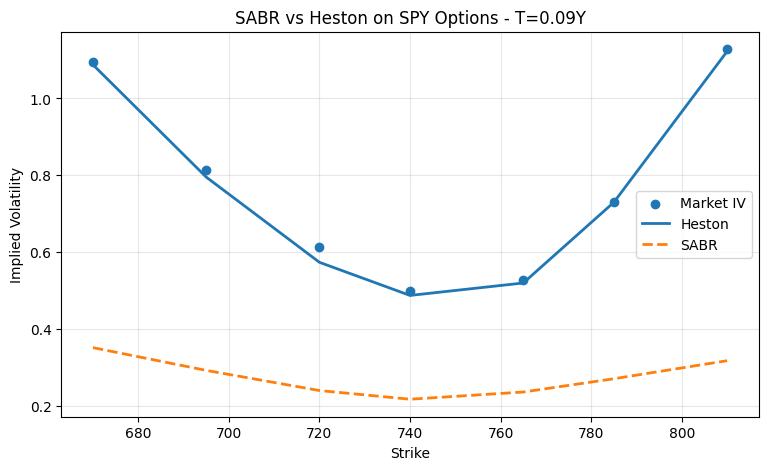

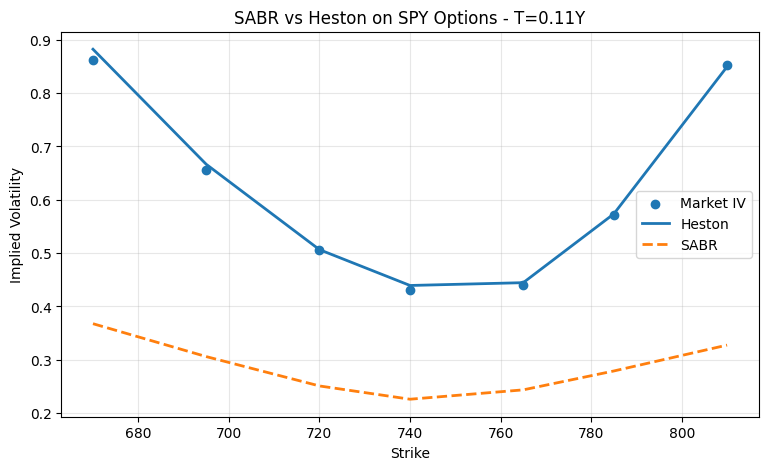

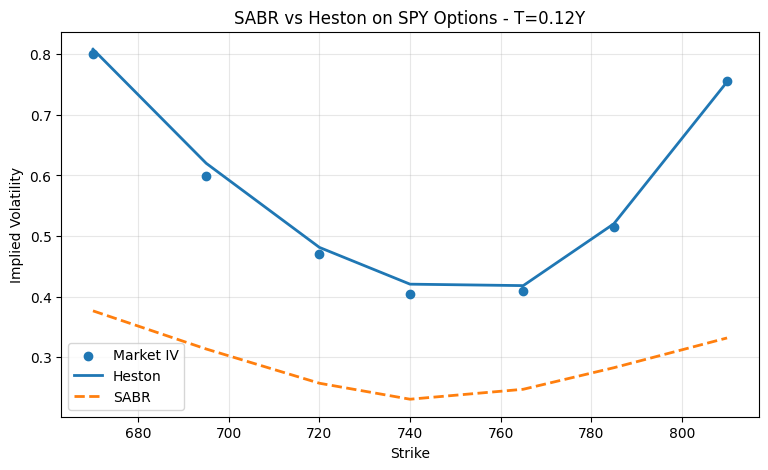

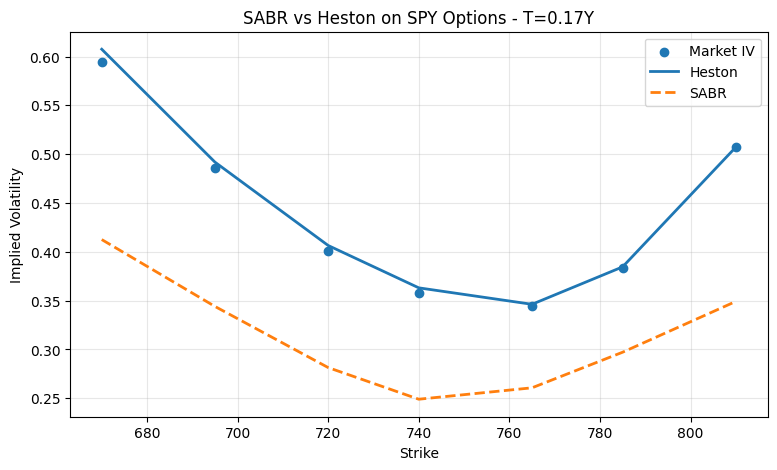

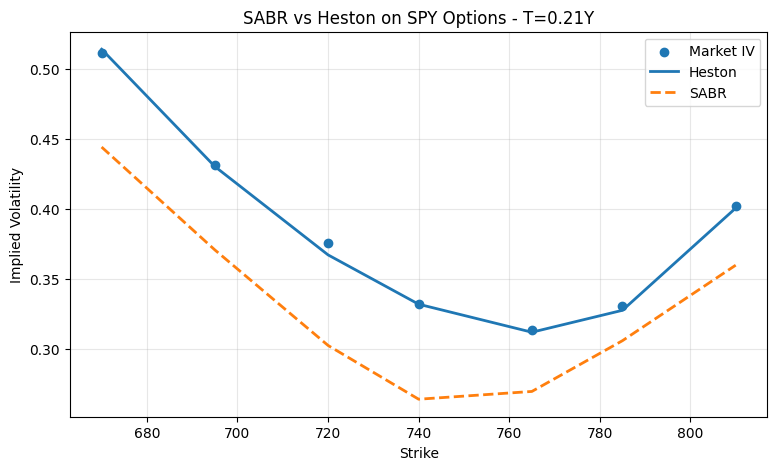

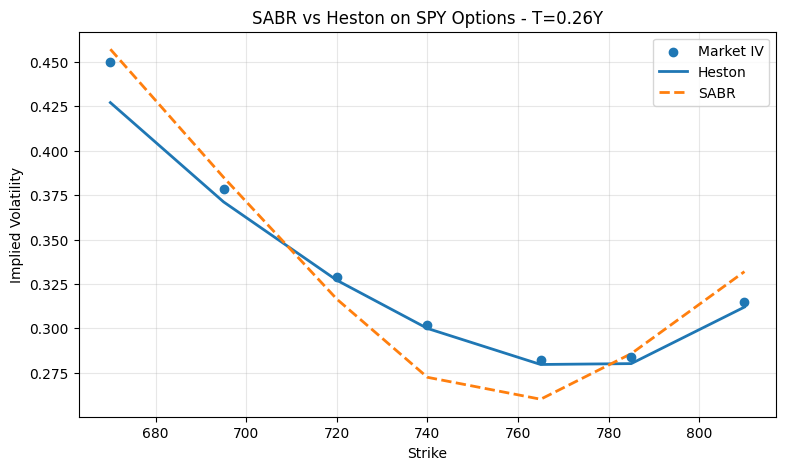

In [36]:
for i, maturity in enumerate(maturities):
    plt.figure(figsize=(9, 5))

    plt.scatter(
        strikes,
        market_vol_surface[i],
        label="Market IV",
        zorder=3,
    )

    plt.plot(
        strikes,
        heston_surface[i],
        label="Heston",
        linewidth=2,
    )

    plt.plot(
        strikes,
        sabr_surface[i],
        label="SABR",
        linestyle="--",
        linewidth=2,
    )

    plt.title(f"SABR vs Heston on {ticker_symbol} Options - T={maturity:.2f}Y")
    plt.xlabel("Strike")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

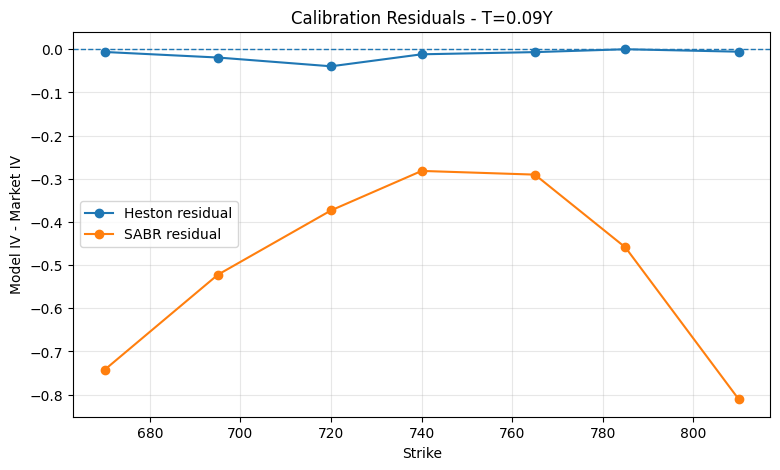

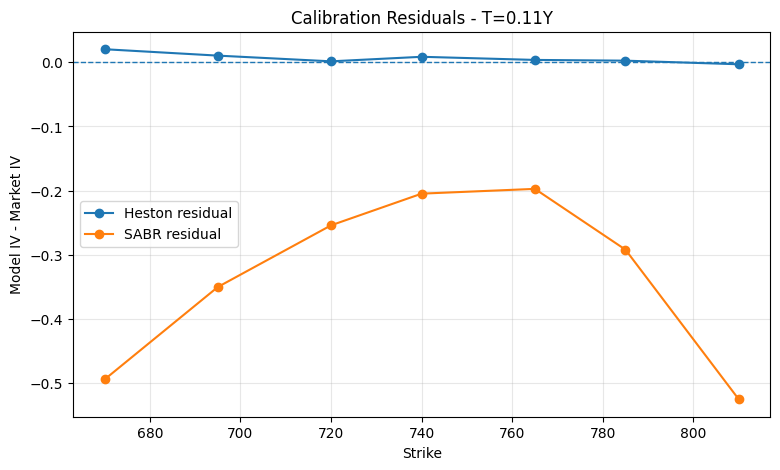

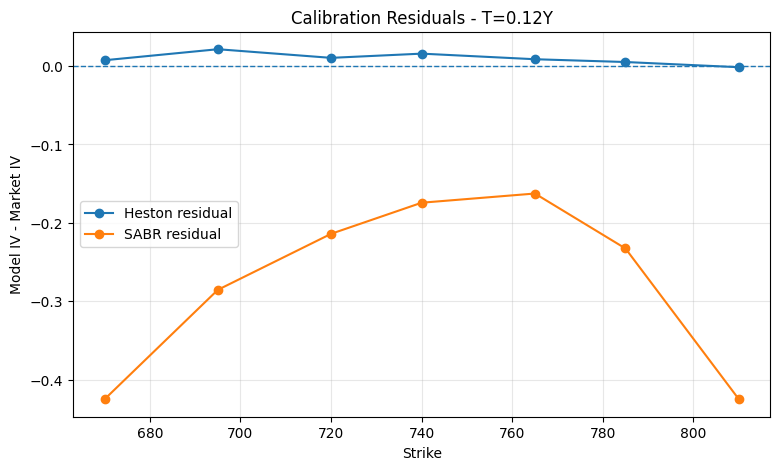

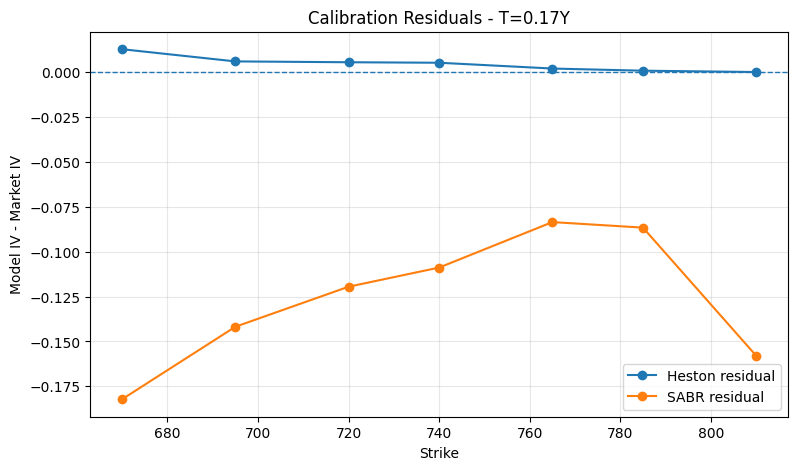

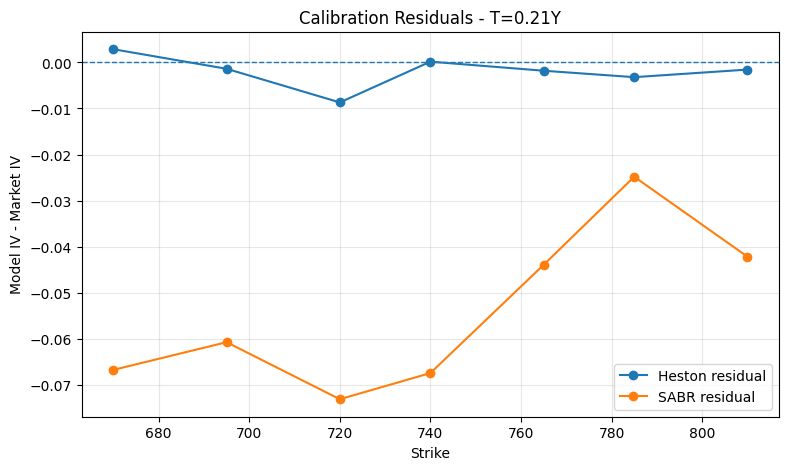

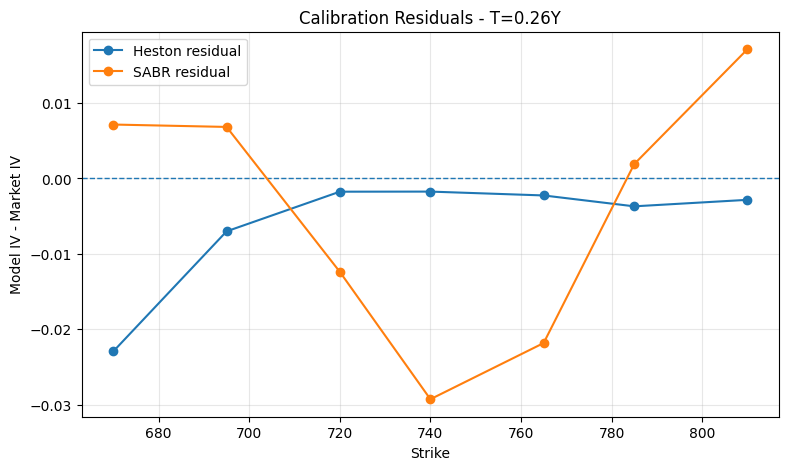

In [37]:
heston_residuals = heston_surface - market_vol_surface
sabr_residuals = sabr_surface - market_vol_surface

for i, maturity in enumerate(maturities):
    plt.figure(figsize=(9, 5))

    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.plot(
        strikes,
        heston_residuals[i],
        marker="o",
        label="Heston residual",
    )

    plt.plot(
        strikes,
        sabr_residuals[i],
        marker="o",
        label="SABR residual",
    )

    plt.title(f"Calibration Residuals - T={maturity:.2f}Y")
    plt.xlabel("Strike")
    plt.ylabel("Model IV - Market IV")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

## Conclusion

This notebook compares SABR and Heston calibrations on real option market data.

The Heston model provides a globally consistent fit across the implied volatility surface, using a single set of stochastic volatility parameters. In this experiment, Heston produces a relatively stable fit across maturities and captures the overall level of the market implied volatility surface.

SABR is calibrated independently for each maturity. It often captures the general shape of the smile, but in some maturities the fitted smile is vertically shifted relative to the market data. This is not necessarily a numerical error: SABR calibration is sensitive to the choice of fixed beta, the forward level, bid-ask noise, short maturities, and the quality of option quotes.

Overall, the results illustrate an important modelling trade-off. Heston offers a more coherent global stochastic volatility framework, while SABR provides local smile flexibility but can be unstable or biased when applied to noisy real market data without additional weighting, filtering, or beta calibration.

A natural extension would be to improve the SABR calibration by introducing vega-weighted errors, bid-ask filtering, liquidity-based weights, and either calibrating beta or testing several fixed beta values.